In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from liffile import LifFile

from skimage import util, exposure
from skimage.io import imread
from skimage.measure import label, regionprops_table, regionprops,  moments_central
from skimage.morphology import  disk, remove_small_objects, binary_dilation, remove_small_holes , erosion, closing, skeletonize, binary_closing, disk, binary_opening, binary_erosion
from skimage.transform import rotate
from skimage.transform import probabilistic_hough_line
from skimage.filters import threshold_sauvola, frangi, sato, threshold_yen, threshold_local, threshold_mean, threshold_li, threshold_minimum, try_all_threshold, threshold_triangle, median, sobel, gaussian, threshold_otsu, sobel_v
from skimage.graph import route_through_array
from skimage.draw import line as sk_line

import napari
from matplotlib.colors import to_rgba

import warnings
warnings.filterwarnings("ignore")


In [ ]:
def label_colormap(color, alpha=1.0):
    rgba = np.array(to_rgba(color))
    rgba[3] = alpha
    return {
    0: np.array([0., 0., 0., 0.]),
    1: rgba
    }

In [366]:
def vertical_brightness_ratio(img, eps=1e-6):
    """
    Measures brightness discontinuity top vs bottom.
    Returns absolute log ratio: abs(log(top/bottom)).
    """
    y = int(img.shape[0] * 0.5)
    a = np.median(img[:y])
    b = np.median(img[y:])
    return float(abs(np.log((a + eps) / (b + eps))))

def fit_line_fast(x, y):
    """
    Fast least-squares line fit y = a*x + b.
    Much faster than np.polyfit for small k.
    """
    n = x.size
    if n < 2:
        return 0.0, float(y[0]) if n else 0.0

    x = x.astype(np.float32, copy=False)
    y = y.astype(np.float32, copy=False)

    xm = x.mean()
    ym = y.mean()

    dx = x - xm
    denom = np.dot(dx, dx)

    if denom == 0:
        return 0.0, float(ym)

    a = np.dot(dx, y - ym) / denom
    b = ym - a * xm
    return float(a), float(b)

def extend_path_to_edges(path_mask, k=5, max_gap=30, edge_tol=0):
    """
    Extend a path so it touches x=0 and x=W-1, but only if endpoints are within max_gap.
    Optimised for speed: argpartition + closed-form line fit.
    """
    m = path_mask.astype(bool).copy()
    H, W = m.shape

    ys, xs = np.nonzero(m)
    n = xs.size
    if n < 2:
        return m

    x_min = int(xs.min())
    x_max = int(xs.max())
    left_gap  = x_min
    right_gap = (W - 1) - x_max

    if left_gap <= edge_tol and right_gap <= edge_tol:
        return m

    if left_gap > max_gap and right_gap > max_gap:
        return m

    kk = min(k, n)

    # ---- LEFT EXTENSION ----
    if left_gap <= max_gap:
        idx = np.argpartition(xs, kk - 1)[:kk]
        a, b = fit_line_fast(xs[idx], ys[idx])

        x0 = x_min
        y0 = int(np.clip(np.rint(a * x0 + b), 0, H - 1))
        y_edge = int(np.clip(np.rint(b), 0, H - 1))

        rr, cc = sk_line(y_edge, 0, y0, x0)
        m[rr, cc] = True

    # ---- RIGHT EXTENSION ----
    if right_gap <= max_gap:
        idx = np.argpartition(xs, n - kk)[-kk:]
        a, b = fit_line_fast(xs[idx], ys[idx])

        x1 = x_max
        y1 = int(np.clip(np.rint(a * x1 + b), 0, H - 1))
        y_edge = int(np.clip(np.rint(a * (W - 1) + b), 0, H - 1))

        rr, cc = sk_line(y1, x1, y_edge, W - 1)
        m[rr, cc] = True

    return m


def extract_boundary(img, thr_func, min_size=100, area_threshold=500, opening_size=3): 
    bw_orig = img > thr_func(img)
    bw = remove_small_objects(bw_orig, min_size=min_size)
    bw = remove_small_holes(bw, area_threshold=area_threshold)
    bw = binary_opening(bw, disk(opening_size))


    labels = label(bw)
    if labels.max() > 0:
        props = regionprops(labels)
        biggest = max(props, key=lambda p: p.area)
        bw = (labels == biggest.label)

    # interface line
    path_mask = bw ^ binary_erosion(bw, disk(1))
    lab = label(path_mask)
    if lab.max() > 0:
        props = regionprops(lab)
        longest = max(props, key=lambda p: p.area) # area == number of pixels
        path_mask = (lab == longest.label)
    return path_mask, bw

from heapq import heappush, heappop

def find_best_left_right_route(mask, edge_margin=30, step_cost=100.0):
    H, W = mask.shape

    left_pts  = np.argwhere(mask[:, :edge_margin])
    right_pts = np.argwhere(mask[:, W-edge_margin:])

    if len(left_pts) == 0 or len(right_pts) == 0:
        m2 = binary_dilation(mask, disk(2))
        left_pts  = np.argwhere(m2[:, :edge_margin])
        right_pts = np.argwhere(m2[:, W-edge_margin:])
        if len(left_pts) == 0 or len(right_pts) == 0:
            return None
        mask = m2

    right_set = {(y, W-edge_margin + x) for y, x in right_pts}

    off_penalty = step_cost * 0.2
    cost = np.where(mask, step_cost, step_cost + off_penalty)

    visited = np.full(mask.shape, False, dtype=bool)
    prev = dict()
    pq = []

    # Multi-source init
    for y, x in left_pts:
        heappush(pq, (0.0, (y, x)))
        prev[(y, x)] = None

    end = None

    while pq:
        c, (y, x) = heappop(pq)
        if visited[y, x]:
            continue
        visited[y, x] = True

        if (y, x) in right_set:
            end = (y, x)
            break

        for dy, dx in [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]:
            ny, nx = y+dy, x+dx
            if 0 <= ny < H and 0 <= nx < W and not visited[ny, nx]:
                nc = c + cost[ny, nx]
                heappush(pq, (nc, (ny, nx)))
                if (ny, nx) not in prev:
                    prev[(ny, nx)] = (y, x)

    if end is None:
        return None

    # Reconstruct path
    path_mask = np.zeros_like(mask, dtype=bool)
    cur = end
    while cur is not None:
        path_mask[cur] = True
        cur = prev[cur]

    return path_mask



def find_ridge_through_plane(img_slice, to_plot=True, ratio_cutoff=0.75):
    # # Gate: decide edge-mode vs ridge-mode
    vr = vertical_brightness_ratio(img_slice)
    mode = "edge" if vr > ratio_cutoff else "ridge"    
    if mode == "edge": 
        H, W = img_slice.shape
        # --- First attempt: Li ---
        img_med = median(img_slice, disk(7))
        path_mask, bw = extract_boundary(img_med, threshold_li)
        title = "li"
        
        # --- Sanity check: boundary too long? ---
        if path_mask.sum() > 1.5 * W:
            title = "minimum"
            path_mask, bw = extract_boundary(img_med, threshold_minimum, min_size = 0, area_threshold = 0, opening_size=0)
        elif path_mask[0, :].any() or path_mask[-1, :].any():
            title = "triangle"
            path_mask, bw = extract_boundary(exposure.adjust_gamma(img_med, gamma=0.2), threshold_triangle, min_size = 0, area_threshold = 0, opening_size=10)
            
        path_mask = extend_path_to_edges(path_mask,  k=5, max_gap=30, edge_tol=0)
                
    else: ####### ridge mode 
        title="ridge"
        img_med = median(img_slice, disk(7))

        resp = sato(img_med, sigmas=np.linspace(2, 8, 10), black_ridges=True)
        resp = exposure.rescale_intensity(resp)
        # if vr>0.4:
        #     thr = threshold_yen(resp)
        # else:
        thr = threshold_otsu(resp)
        bw = resp > thr

        bw = binary_closing(bw, footprint=disk(9))
        bw = remove_small_objects(bw, min_size=600)
        skel = skeletonize(bw)
        lab = label(skel)
        if lab.max() > 0:
            props = regionprops(lab)
            props_sorted = sorted(props, key=lambda p: p.area, reverse=True)
            labels_to_keep = [p.label for p in props_sorted[:3]]
            skel_main = np.isin(lab, labels_to_keep)
        else:
            skel_main = skel

        path_mask = find_best_left_right_route(skel_main)
        
        if path_mask is None:
            print(f"no path mask found, retrying on full skeleton")
            plt.imshow(skel)
            path_mask = find_best_left_right_route(skel)
        if path_mask is not None:
            print("now extending on ridge")
            path_mask = extend_path_to_edges(path_mask,  k=5, max_gap=50, edge_tol=0)

    if to_plot:
        fig, ax = plt.subplots(ncols=3, figsize=(6, 3))
        ax[0].imshow(img_slice, cmap="gray")
        ax[1].imshow(bw, cmap="gray")
        ax[2].imshow(img_slice, cmap="gray")
        ax[0].set_title("input")
        ax[1].set_title(title)
        ax[2].set_title("path")
        if path_mask is not None:
            y, x = np.nonzero(path_mask)
            ax[2].scatter(x, y, s=2, c="red")
        for a in ax:
            a.axis("off")
        plt.suptitle(f"Mode:{mode}, Brightness ratio:{vr}")
        plt.tight_layout()
        plt.show()
    print(f"Mode={mode}, threshold={title}")
    return path_mask, mode, vr

In [367]:
# ----------------------------
# Helper: line -> y(x) profile
# ----------------------------
def _pathmask_to_profile_y(pm):
    H, W = pm.shape
    y, x = np.nonzero(pm)
    if y.size < 2:
        return None
    order = np.argsort(x)
    x = x[order].astype(float)
    y = y[order].astype(float)
    x_u, idx = np.unique(x, return_index=True)
    y_u = y[idx]
    if x_u.size < 2:
        return None
    x_grid = np.arange(W, dtype=float)
    return np.interp(x_grid, x_u, y_u, left=y_u[0], right=y_u[-1])


# ============================================================
# 1) Iterate through z -> return lines and zs where a line exists
# ============================================================
def collect_lines_over_z(vol_zyx, ratio_cutoff=0.75, discard_top_bottom=True, to_plot=True):
    """
    Returns:
      lines: dict[z] -> bool path_mask
      profiles: dict[z] -> float y(x) profile (len W)
      found_zs: sorted list of z where a valid line exists
    """
    Z, H, W = vol_zyx.shape
    lines = {}
    profiles = {}
    found_zs = []

    for z in range(Z):
        pm, mode, vr = find_ridge_through_plane(vol_zyx[z], to_plot=to_plot, ratio_cutoff=ratio_cutoff)
        if pm is None or pm.sum() == 0:
            continue
        pm = pm.astype(bool)
        if discard_top_bottom and (pm[0, :].any() or pm[-1, :].any()):
            continue

        yx = _pathmask_to_profile_y(pm)
        if yx is None:
            continue

        lines[z] = pm
        profiles[z] = yx
        found_zs.append(z)

    return lines, profiles, sorted(found_zs)


# ============================================================
# 2) Keep all low-z lines; filter out high-z lines that diverge
# ============================================================
def keep_similar_high_z(lines, profiles, found_zs, warmup=5, diff_thresh_px=None, consec_bad=2):
    """
    Starts at first found z, includes everything upward until the high-z end diverges.
    "Difference" is median |y(x) - consensus(x)| where consensus is median of warmup+accepted slices.

    Returns:
      kept_zs: list[int]
      kept_lines: dict[z]->bool mask
    """
    if len(found_zs) == 0:
        return [], {}

    found_zs = sorted(found_zs)
    kept_zs = [found_zs[0]]
    kept_lines = {found_zs[0]: lines[found_zs[0]]}
    consensus_stack = [profiles[found_zs[0]]]

    bad_run = 0

    # auto-threshold from early changes if not provided
    def _auto_thresh():
        if len(consensus_stack) < 3:
            return None
        ds = []
        for i in range(1, len(consensus_stack)):
            ds.append(np.median(np.abs(consensus_stack[i] - consensus_stack[i-1])))
        ds = np.array(ds, float)
        if ds.size == 0:
            return None
        q50, q90 = np.quantile(ds, 0.5), np.quantile(ds, 0.9)
        return float(q50 + 2.0 * (q90 - q50))

    # walk through found z's in order (not necessarily contiguous)
    for z in found_zs[1:]:
        cons = np.median(np.stack(consensus_stack, axis=0), axis=0)
        diff = float(np.median(np.abs(profiles[z] - cons)))

        if len(consensus_stack) >= warmup:
            thr = diff_thresh_px if diff_thresh_px is not None else _auto_thresh()
            if thr is not None and diff > thr:
                bad_run += 1
            else:
                bad_run = 0

            if bad_run >= consec_bad:
                break  # stop: high-z has diverged

        # accept
        kept_zs.append(z)
        kept_lines[z] = lines[z]
        consensus_stack.append(profiles[z])

    return kept_zs, kept_lines


# ============================================================
# 3) Build segmentations from kept lines + compute areas/volumes
# ============================================================
def segment_from_lines_and_measure(vol_shape_zyx, kept_zs, profiles, side="below"):
    """
    Builds two 3D masks over ONLY kept_zs:
      region_zyx: pixels on chosen side of barrier (above/below)
      other_zyx:  opposite side
    Also returns:
      area_by_z: cross-sectional area (pixels) on chosen side for each kept z
      volume_side / volume_other: voxel counts over kept_zs only
    """
    Z, H, W = vol_shape_zyx
    region = np.zeros((Z, H, W), dtype=bool)
    other = np.zeros((Z, H, W), dtype=bool)
    area_by_z = {}

    Y = np.arange(H)[:, None]  # (H,1)

    for z in kept_zs:
        yx = profiles.get(z, None)
        if yx is None:
            continue
        yy = np.clip(np.round(yx).astype(int), 0, H - 1)[None, :]  # (1,W)

        below = (Y >= yy)
        above = (Y <= yy)

        if side == "below":
            region[z] = below
            other[z] = ~below
            area_by_z[z] = int(below.sum())
        elif side == "above":
            region[z] = above
            other[z] = ~above
            area_by_z[z] = int(above.sum())
        else:
            raise ValueError("side must be 'below' or 'above'")

    volume_side = int(region.sum())
    volume_other = int(other.sum())  # only nonzero on kept_zs

    return region, other, area_by_z, volume_side, volume_other

In [368]:
folder = Path(r"Z:\Maria Cuende\0_Projects\0_Placenta\Barrier integrity\20260115-22_Exp6-Thalidomide-Ibuprofen")
lif_files = list(folder.glob("*.lif"))
print(len(lif_files))

lif_path = lif_files[1]
image_index = 8


dextran_channel = 2
with LifFile(lif_path) as lif:
    img = lif.images[image_index]
    print(f"Opening image {lif.name}, which has dimensions {getattr(img, 'dims', None)} and shape {img.shape}")
    img = img.asarray()
dextran_t0 = img[0, dextran_channel, :, :, :]
print("dextran_t0 shape:", dextran_t0.shape)


    # for z in [5,7,12,15,18,20,25]:
    #     path_mask, mode, vr = find_ridge_through_plane(dextran_t0[z, :, :], to_plot=True)

2
Opening image Exp6_20260122_Thalidomide-Ibuprofen.lif, which has dimensions ('T', 'C', 'Z', 'Y', 'X') and shape (4, 3, 41, 512, 512)
dextran_t0 shape: (41, 512, 512)


now extending on ridge


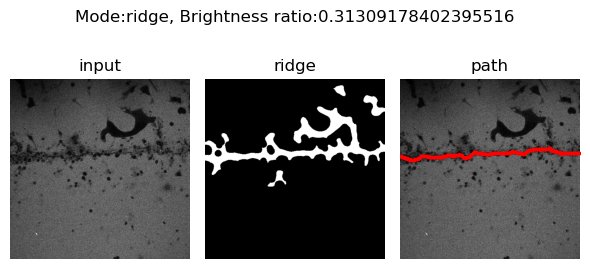

Mode=ridge, threshold=ridge
now extending on ridge


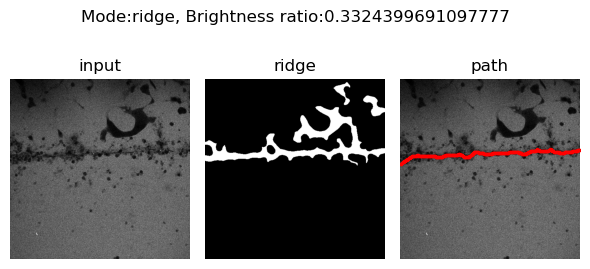

Mode=ridge, threshold=ridge
now extending on ridge


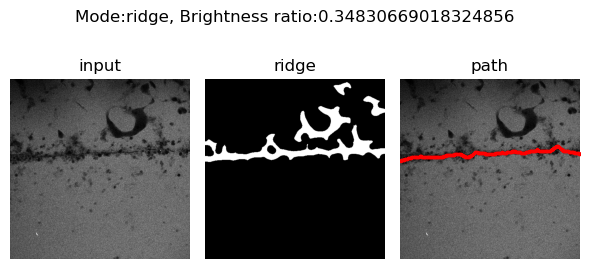

Mode=ridge, threshold=ridge
now extending on ridge


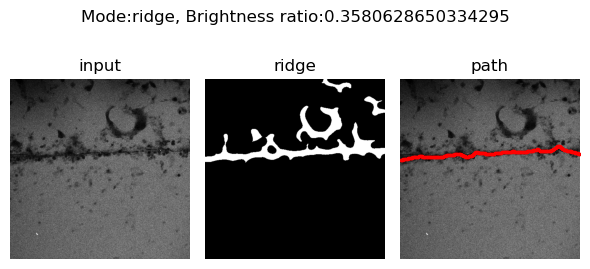

Mode=ridge, threshold=ridge
now extending on ridge


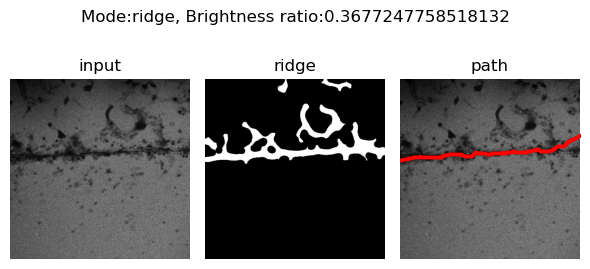

Mode=ridge, threshold=ridge
now extending on ridge


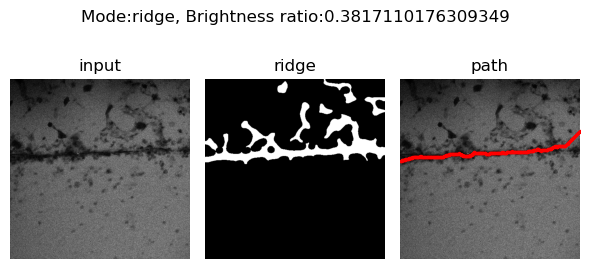

Mode=ridge, threshold=ridge
now extending on ridge


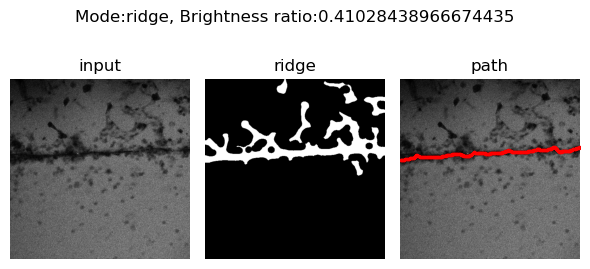

Mode=ridge, threshold=ridge
now extending on ridge


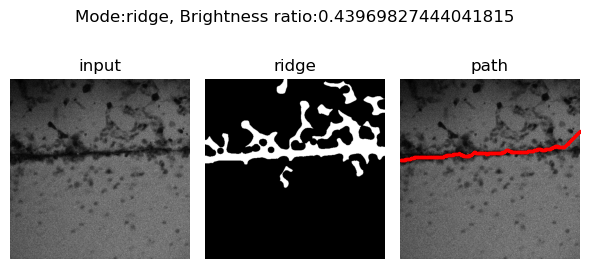

Mode=ridge, threshold=ridge
now extending on ridge


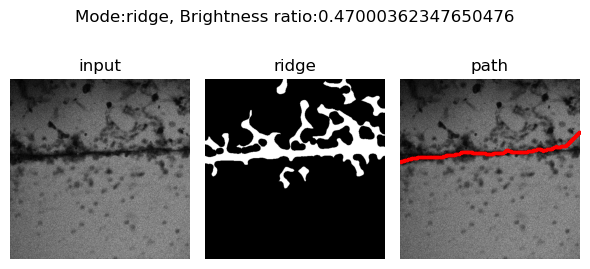

Mode=ridge, threshold=ridge
now extending on ridge


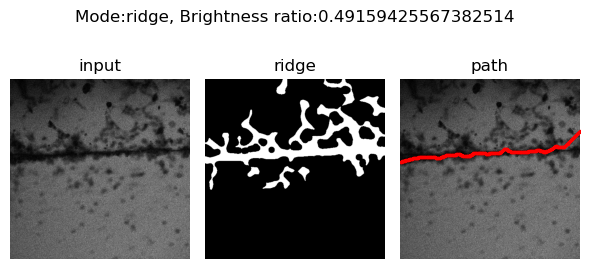

Mode=ridge, threshold=ridge
now extending on ridge


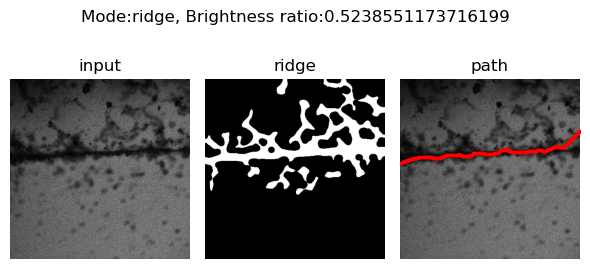

Mode=ridge, threshold=ridge
now extending on ridge


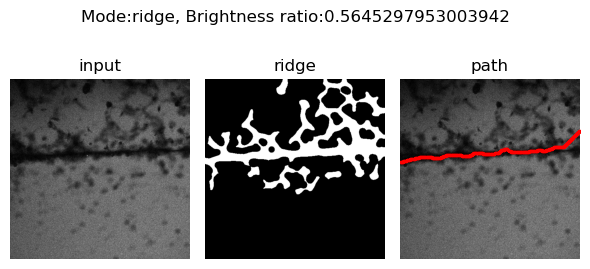

Mode=ridge, threshold=ridge
now extending on ridge


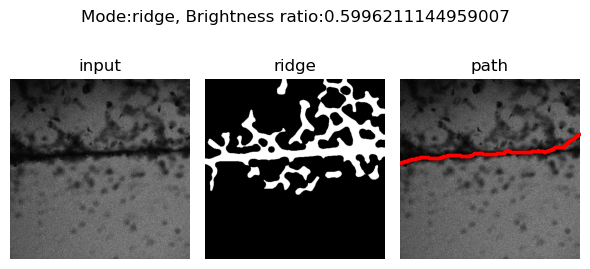

Mode=ridge, threshold=ridge
now extending on ridge


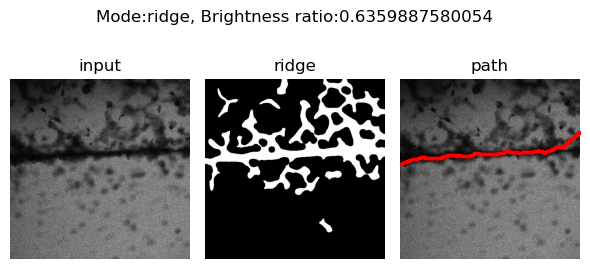

Mode=ridge, threshold=ridge
now extending on ridge


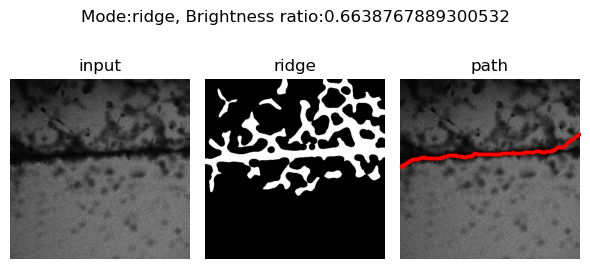

Mode=ridge, threshold=ridge
now extending on ridge


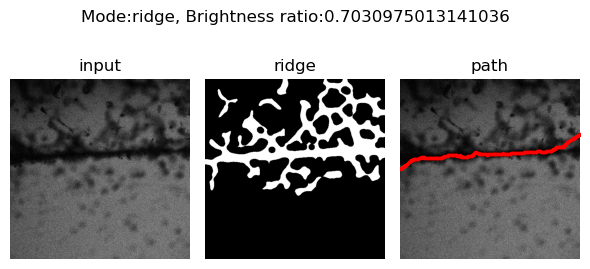

Mode=ridge, threshold=ridge
now extending on ridge


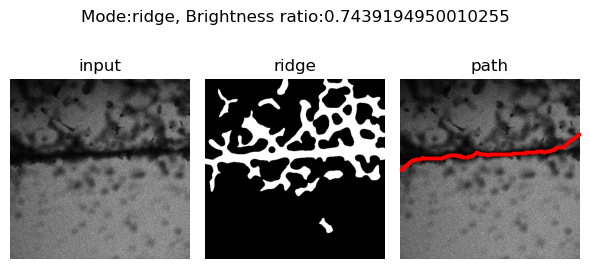

Mode=ridge, threshold=ridge


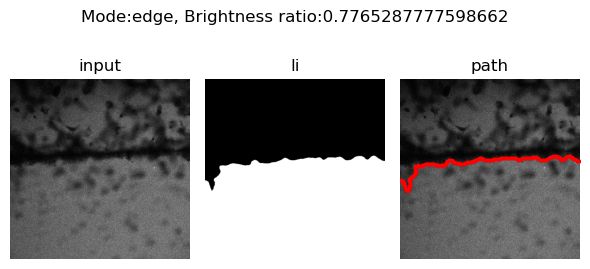

Mode=edge, threshold=li


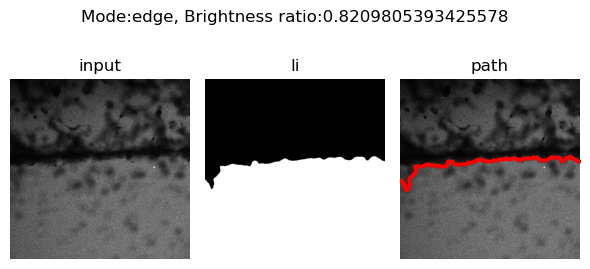

Mode=edge, threshold=li


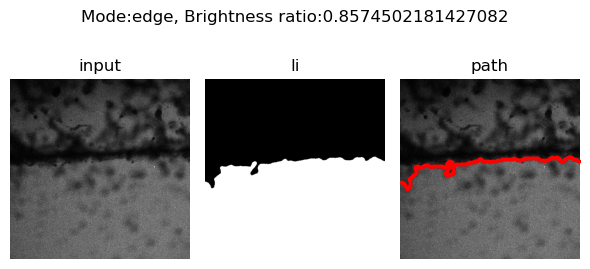

Mode=edge, threshold=li


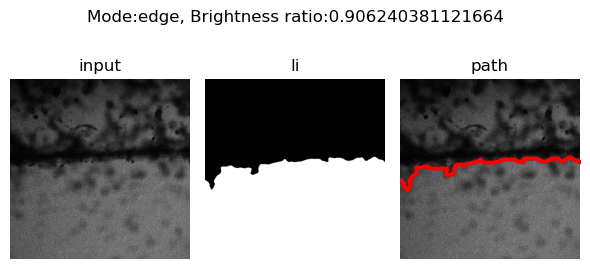

Mode=edge, threshold=li


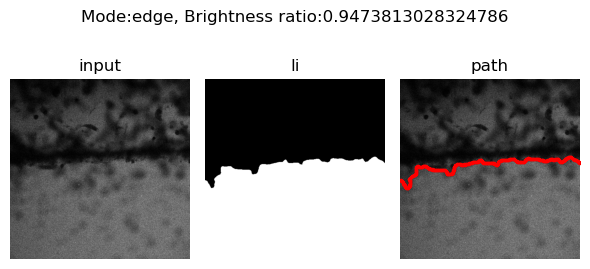

Mode=edge, threshold=li


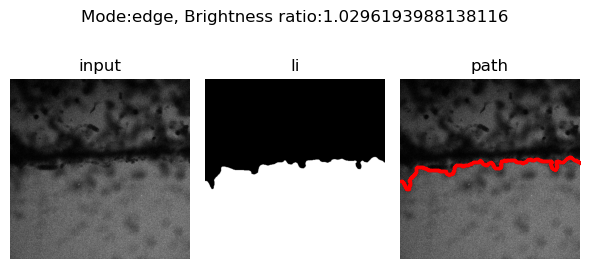

Mode=edge, threshold=li


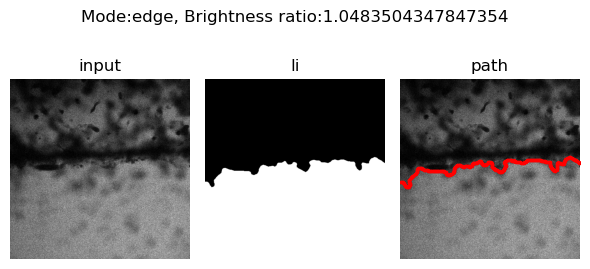

Mode=edge, threshold=li


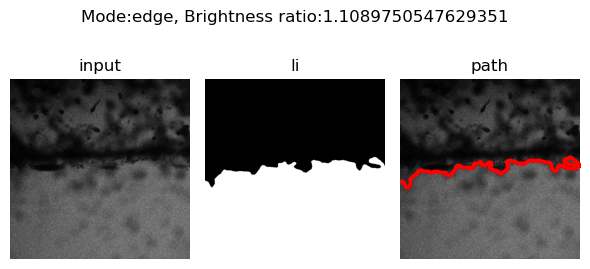

Mode=edge, threshold=li


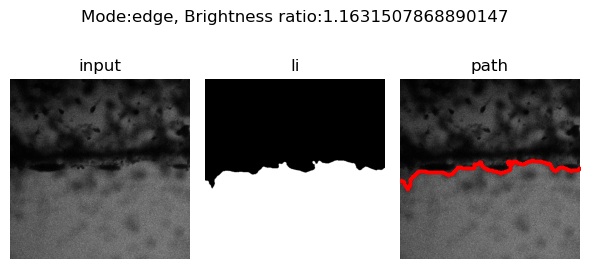

Mode=edge, threshold=li


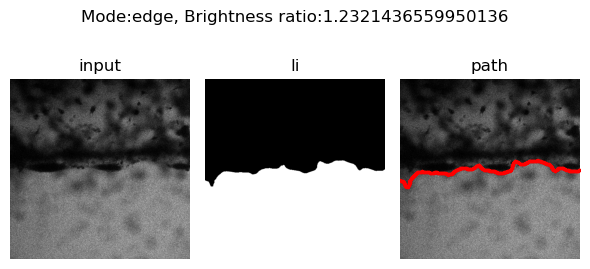

Mode=edge, threshold=li


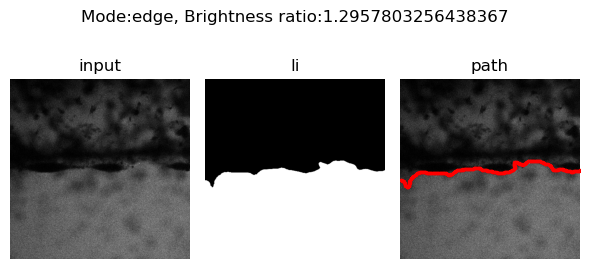

Mode=edge, threshold=li


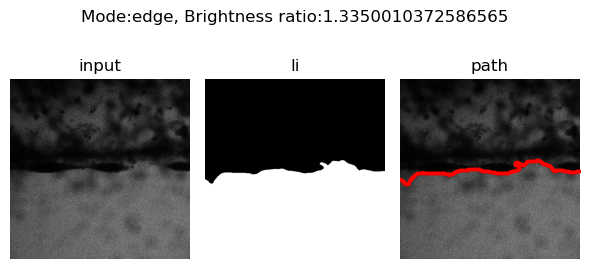

Mode=edge, threshold=li


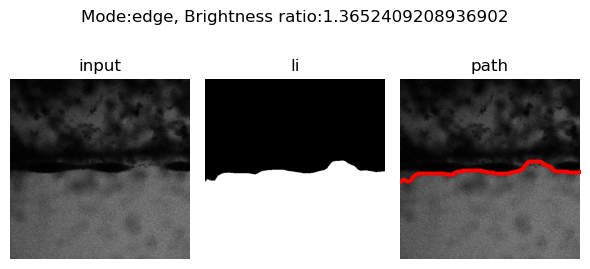

Mode=edge, threshold=li


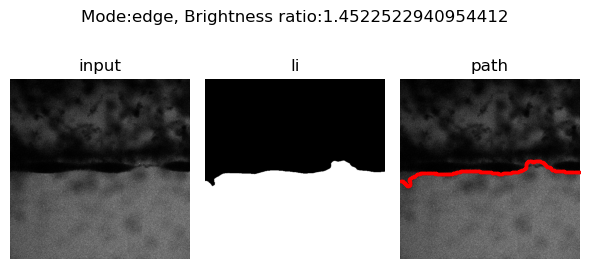

Mode=edge, threshold=li


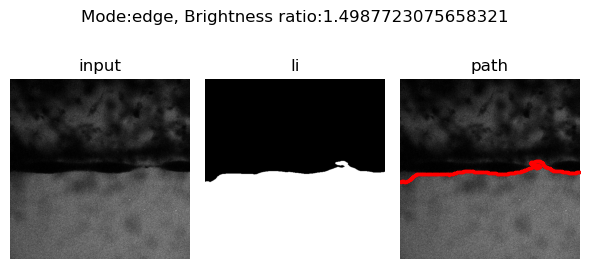

Mode=edge, threshold=li


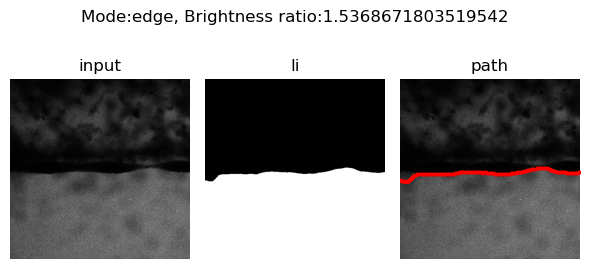

Mode=edge, threshold=li


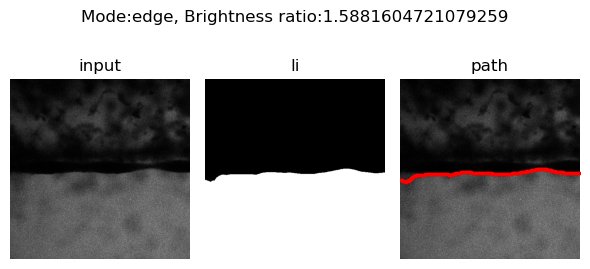

Mode=edge, threshold=li


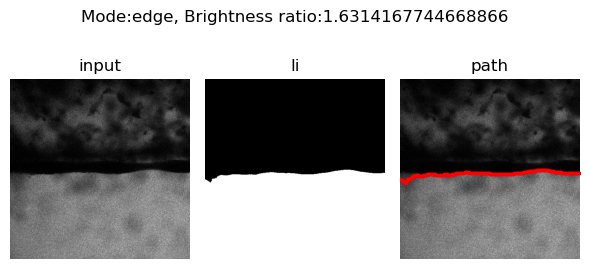

Mode=edge, threshold=li


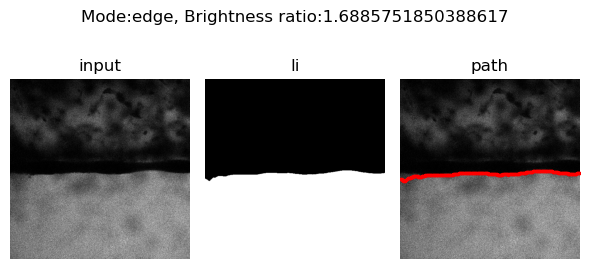

Mode=edge, threshold=li


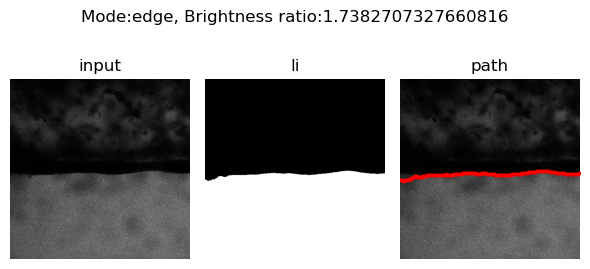

Mode=edge, threshold=li


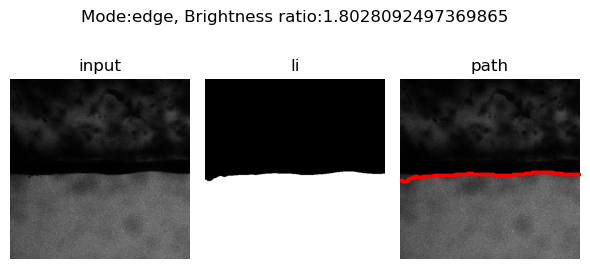

Mode=edge, threshold=li


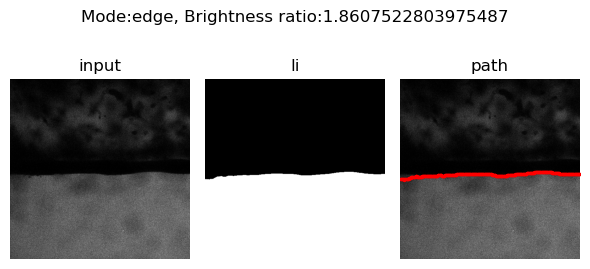

Mode=edge, threshold=li


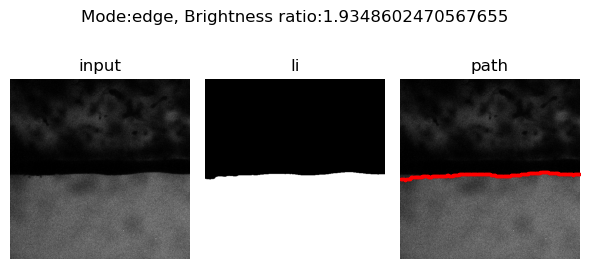

Mode=edge, threshold=li


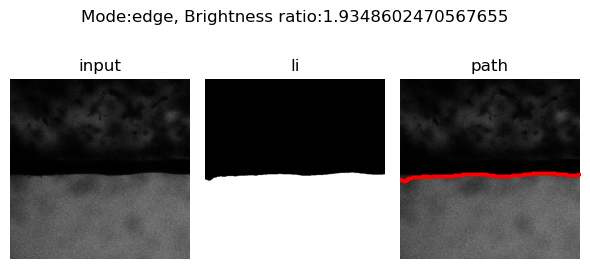

Mode=edge, threshold=li


In [369]:
# 1) lines + zs
lines, profiles, found_zs = collect_lines_over_z(dextran_t0, ratio_cutoff=0.75, to_plot = True)


In [388]:

# 2) keep all low-z, drop divergent high-z
kept_zs, kept_lines = keep_similar_high_z(
    lines, profiles, found_zs,
    warmup=5,
    diff_thresh_px=10,   # auto; or set e.g. 5-10
    consec_bad=2
)


In [389]:

# 3) segmentation + area/volume (ONLY over kept_zs)
region_zyx, other_zyx, area_by_z, vol_region, vol_other = segment_from_lines_and_measure(
    dextran_t0.shape, kept_zs, profiles, side="below"   # or "above"
)

print("found_zs:", found_zs[:10], "...", found_zs[-10:])
print("kept_zs:", kept_zs[0], "->", kept_zs[-1], f"(n={len(kept_zs)})")
print("area_by_z (first 5):", [(z, area_by_z[z]) for z in kept_zs[:5] if z in area_by_z])
print("volume side:", vol_region, "volume other:", vol_other)

found_zs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ... [31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
kept_zs: 0 -> 17 (n=18)
area_by_z (first 5): [(0, 153256), (1, 153310), (2, 153759), (3, 153917), (4, 155634)]
volume side: 2770891 volume other: 1947701


In [374]:
def lines_dict_to_label_volume(lines, Z, H, W):
    lab = np.zeros((Z, H, W), dtype=np.uint8)
    for z, pm in lines.items():
        lab[z][pm] = 1
    return lab

In [375]:


viewer = napari.Viewer()
viewer.add_labels(region_zyx , colormap=label_colormap("dodgerblue"))
viewer.add_labels(other_zyx, colormap={0: np.array([0., 0., 0., 0.]), 1:np.array([1.,0.,0.,1.])} )
viewer.add_image(dextran_t0)
viewer.add_labels(lines_dict_to_label_volume(lines, dextran_t0.shape[0], dextran_t0.shape[1], dextran_t0.shape[2]))


<Labels layer 'Labels' at 0x15f78684e50>